<a href="https://colab.research.google.com/github/Goal48/SMS-Spam-Detector/blob/main/SMS_Spam_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SMS_Spam_Detector/spam.csv', encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df = df.drop(['Unnamed: 4','Unnamed: 3','Unnamed: 2'],axis = 1)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.rename(columns={'v1':'target','v2':'SMS'},inplace = True)
df.head(3)

,target,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [8]:
def replace_target(df, column):
    df[column] = df[column].replace({
        'ham': 0,
        'spam': 1
    })

replace_target(df, 'target')

/tmp/ipykernel_10791/4096424385.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].replace({


In [9]:
df.head(3)

,target,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df = df.drop_duplicates(keep='first')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
Counts = df['target'].value_counts()

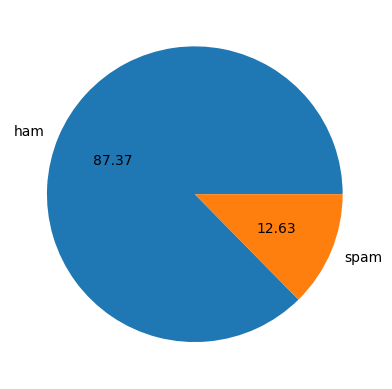

In [14]:
import matplotlib.pyplot as plt

plt.pie(Counts , labels=['ham','spam'],autopct='%0.2f')
plt.show()

Data is imbalanced

In [15]:
import nltk

In [16]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
df['num_character'] = df['SMS'].apply(lambda x : len(x))
df.head(3)

,target,SMS,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155


In [19]:
df['num_words'] = df['SMS'].apply(lambda x : len(nltk.word_tokenize(x)))
df.head(3)

,target,SMS,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37


In [20]:
df['num_sent'] = df['SMS'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.head(3)

,target,SMS,num_character,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2


In [21]:
df[['num_sent','num_words','num_character']].describe()

,num_sent,num_words,num_character
count,5169.000000,5169.000000,5169.000000
mean,1.965564,18.455794,78.977945
std,1.448541,13.324758,58.236293
min,1.000000,1.000000,2.000000
25%,1.000000,9.000000,36.000000
50%,1.000000,15.000000,60.000000
75%,2.000000,26.000000,117.000000
max,38.000000,220.000000,910.000000


In [22]:
df[df['target'] == 0][['num_sent', 'num_words', 'num_character']].describe()

,num_sent,num_words,num_character
count,4516.000000,4516.000000,4516.000000
mean,1.820195,17.123782,70.459256
std,1.383657,13.493970,56.358207
min,1.000000,1.000000,2.000000
25%,1.000000,8.000000,34.000000
50%,1.000000,13.000000,52.000000
75%,2.000000,22.000000,90.000000
max,38.000000,220.000000,910.000000


In [23]:
df[df['target'] == 1][['num_sent', 'num_words', 'num_character']].describe()

,num_sent,num_words,num_character
count,653.000000,653.000000,653.000000
mean,2.970904,27.667688,137.891271
std,1.488425,7.008418,30.137753
min,1.000000,2.000000,13.000000
25%,2.000000,25.000000,132.000000
50%,3.000000,29.000000,149.000000
75%,4.000000,32.000000,157.000000
max,9.000000,46.000000,224.000000


<Axes: xlabel='num_sent', ylabel='Count'>

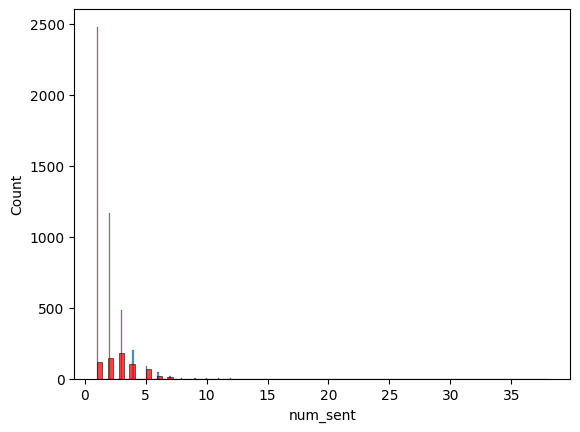

In [24]:
## Histogram Plot
import seaborn as sns

sns.histplot(df[df['target']==0]['num_sent'])
sns.histplot(df[df['target']==1]['num_sent'],color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

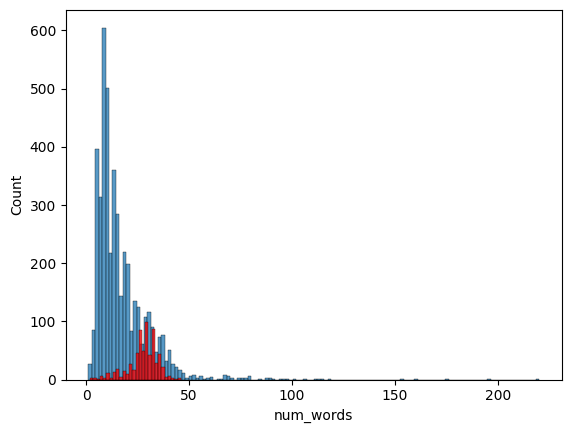

In [25]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color = 'red')

<Axes: xlabel='num_character', ylabel='Count'>

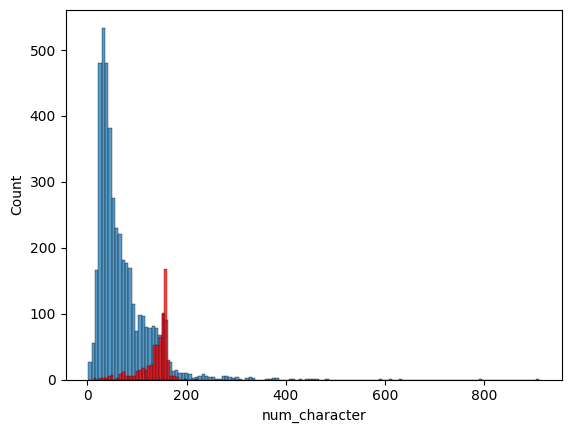

In [26]:
sns.histplot(df[df['target']==0]['num_character'])
sns.histplot(df[df['target']==1]['num_character'],color = 'red')

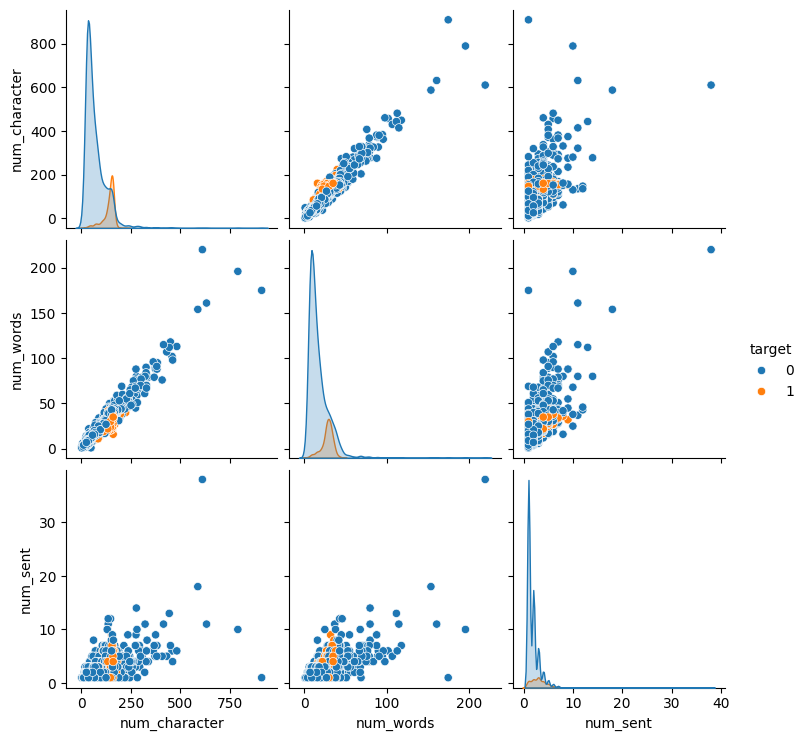

In [27]:
sns.pairplot(df,hue = 'target')

<Axes: >

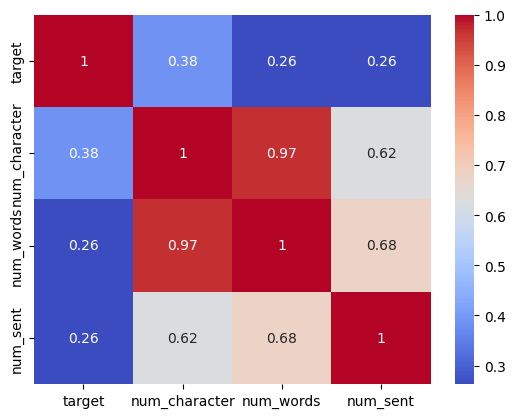

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

Data Preprocessing



1.   LowerCase

1.   Tokennization
2.   Removing Specail Character


2.   Rmoving stop words and puncation

1.   stemming





In [45]:
nltk.download('stopwords')
from nltk.corpus import stopwords
import string


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [49]:
from nltk.stem import porter
from nltk.stem.porter import PorterStemmer
porter = PorterStemmer()

In [61]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for word in text:
      if word.isalnum():
          y.append(word)

  text = y[:]
  y.clear()
  for word in text:
    if word not in stopwords.words('english') and word not in string.punctuation:
      y.append(word)

  text = y[:]
  y.clear()
  for i in text:
    y.append(porter.stem(i))
  return " ".join(y)

In [62]:
df['transform_SMS'] = df['SMS'].apply(transform_text)

In [63]:
df.head()

,target,SMS,num_character,num_words,num_sent,transform_SMS
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [64]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
)

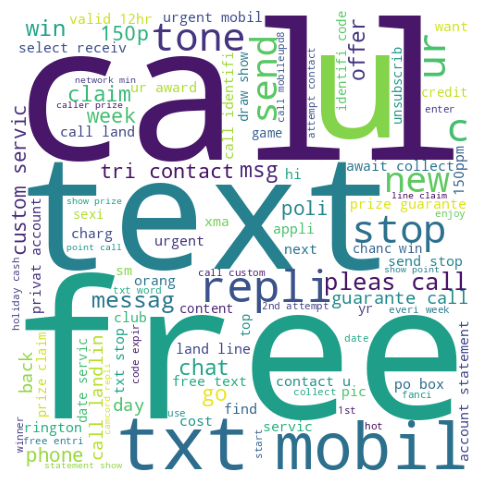

In [66]:
spam_wc = wc.generate(
    df[df['target'] == 1]['transform_SMS'].str.cat(sep=" ")
)

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

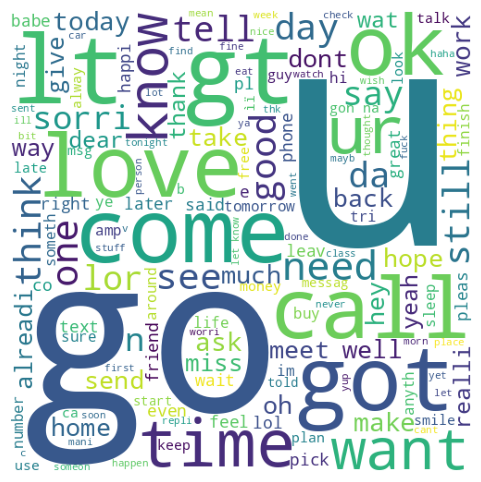

In [67]:
ham_wc = wc.generate(
    df[df['target'] == 0]['transform_SMS'].str.cat(sep=" ")
)

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

In [71]:
## Top 30 words are used in spam
spam_corpus = []
for msg in df[df['target']==1]['transform_SMS'].tolist():
  for word in msg.split() :
    spam_corpus.append(word)


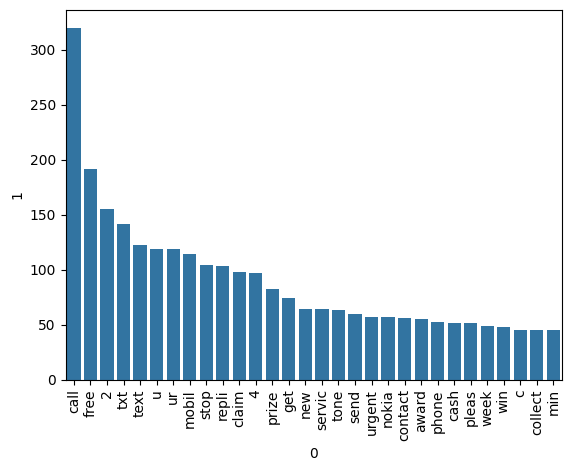

In [77]:

from collections import Counter
common_words = pd.DataFrame(
    Counter(spam_corpus).most_common(30)
)

sns.barplot(
    x=common_words[0],
    y=common_words[1]
)

plt.xticks(rotation='vertical')
plt.show()

In [78]:
## Top 30 words are used in ham
ham_corpus = []
for msg in df[df['target']==0]['transform_SMS'].tolist():
  for word in msg.split() :
    ham_corpus.append(word)

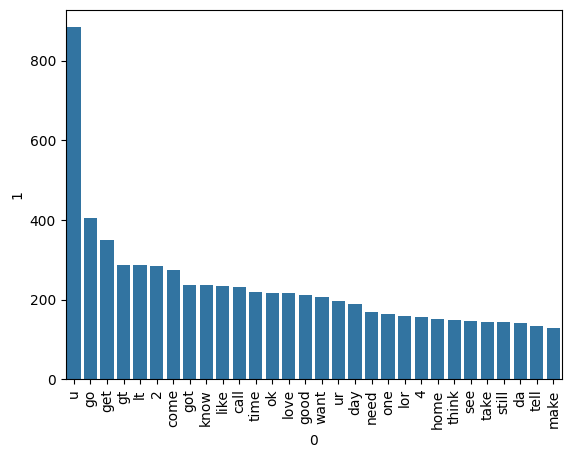

In [79]:
common_words = pd.DataFrame(
    Counter(ham_corpus).most_common(30)
)

sns.barplot(
    x=common_words[0],
    y=common_words[1]
)

plt.xticks(rotation='vertical')
plt.show()